## Homework 2 : Clustering Gaussian Mixtures

**Reminder:** This time we will penalize excessively long answers, i.e. if you cannot answer a question with 1-5 sentences, you should think again.

In this homework you will perform Gibbs sampling on a Gaussian Mixture Model (GMM). You will compute the posterior distribution of a general Gaussian Mixture, generate data from it (a ground truth), sample the equilibrium distribution through Gibbs sampling and check if the retrieved model resembles the original one that truly generated your data.

In [1]:
#Import the necessary packages. You may want to import other ones if needed.
from sklearn.mixture import GaussianMixture as GMM
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm
from scipy.optimize import linear_sum_assignment
np.random.seed(42)

## Exercise 1 (6 pt) - Theory Questions

In this first part we will recall concepts dealt in class and in the notes of the course, with small variations. Please refer to Chapter $8.1$ of the lecture notes for the full details on Clustering and the setting below.

Consider a set $X \in \mathbb{R}^{n \times d}$ of unlabelled data, i.e., a set of $n \in \mathbb{N}$ objects with $d \in \mathbb{N}$ features respectively.

The Loss function that a Gaussian Mixture Model (GMM) aims at minimizing is the following:
$$
    \mathcal{L}(U,V) := \frac{1}{n}\sum_{\mu=1}^n\sum_{i=1}^d \left( X_{\mu i } - \sum_{a=1}^k u_{a i} v_{\mu a} \right)^2
$$

where the vectors $v_\mu \in \mathbb{R}^k$ are the one-hot encoded representations of the clustering assignment of points, and $u_a \in \mathbb{R}^d$ are coordinates of the cluster centers.

The size of the clusters is encoded in the prior of the label assignments:

$$P_{v}(V) = \prod_{\mu=1}^n P_{v}(v_\mu) = \prod_{\mu=1}^n \left( \sum_{a=1}^k \pi_a\delta(e_a - v_\mu) \right)$$

where $\sum_a \pi_a = 1 $ ($\pi_a \in (0,1)$ are the fractions corresponding to the size of cluster $a$ and they are called weights and $e_a$ is a one-hot encoded vector of size $k$ which takes value 1 at the position $a$ and zero elsewhere).



In this setting, the important parameters that define our model are the cluster centers, the cluster assignments and the weights of each cluster. All these informations are encoded in the class GaussianMixture of the library sklearn, that is imported above.

**Question 1 (1 pt):** You are given an histogram of $n=4600$ points generated with 3 Gaussian distributions in $d=1$ dimensions. For this first question, create a Gaussian Mixture Model (GMM) from the package GMM and fit the points of the histogram.

Replot the histogram of raw points along with the fitted curve (GMM) and print the fitted values of the weights, the means and the covariances of the Gaussians found by the model.

Remark: in k-means and in GMM you have to specify the number of clusters.

(-10.0, 20.0)

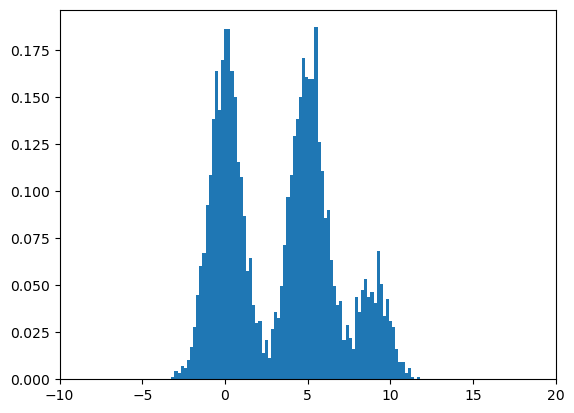

In [22]:
x = np.concatenate([np.random.normal(0, 1, 2000),
                    np.random.normal(5, 1, 2000),
                    np.random.normal(9, 1, 600)])     # concatenates the three gaussian-distributed vectors
x=x.reshape(-1,1)

plt.hist(x, 80, density=True)                          # density=True normalizes the histogram
plt.xlim(-10, 20)

(array([[8.9093236 ],
        [0.04511381],
        [4.98336285]]),
 array([[[0.97292019]],
 
        [[0.97745714]],
 
        [[0.99493571]]]),
 array([0.13205806, 0.4346803 , 0.43326164]))

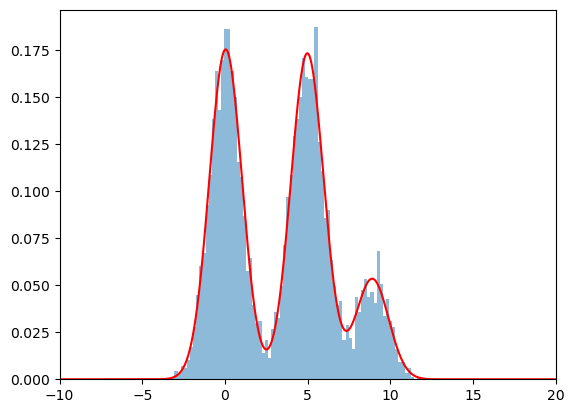

In [23]:
### Answer
clf = GMM(3, max_iter=500).fit(x)
xpdf = np.linspace(-10, 20, 1000)
density = np.array([np.exp(clf.score([[xp]])) for xp in xpdf])
plt.hist(x, 80, density=True, alpha=0.5)
plt.plot(xpdf, density, c='red')
plt.xlim(-10, 20)

clf.means_ , clf.covariances_ , clf.weights_

Note: for practical purposes you will use the function GMM. However, for the purpose of this homework you will have to write from scratch the functions needed in the following.

Now consider the following framework for generating synthetic data:

\begin{equation}
X_{\mu i} = \sqrt{\frac{\rho}{d}} \sum_{a=1}^k v^{*}_{\mu a} u^{*}_{ai} + \xi_{\mu i}
\end{equation}

where $v^{*}_{\mu}$ is the ground-truth one-hot vector, encoding the cluster memberships of data-point $X_{\mu}$, while $u^{*}_{a}$ is the ground-truth centre of cluster $a$.
The additional term $ \xi_{\mu i} \sim \mathcal{N}(0,1)$ corresponds to the noise, here assumed to be the same for all clusters ($V \in \mathbb{R}^{n\times k}$, $U\in \mathbb{R}^{k\times d}$ and $\xi \in \mathbb{R}^{n \times d}$ are matrices!) . The factor $\frac{1}{\sqrt{d}}$ corresponds to the scaling for which the model behaves interestingly.

The parameter $\rho>0$ is called "signal-to-noise ratio" and indicates the relative fraction of the information you want to retrieve, in this case the cluster centers and the label assignment, with respect to the noise through which your data are corrupted.

The goal of the excercise is to infer the ground-truth,  that is the cluster centers $U^*$ and the cluster assignment of points $V^*$, given the noisy observations $X_{\mu i} $. We do it in a Bayesian setting.

**Question 2 (1 pt):** What do you expect to happen to the inference problem, i.e. recovering the true centres of clusters and the true labels of points, when $\rho$ is very small ? What do you expect to happen when $\rho$ is very large? What could happen for intermediate values of $\rho$ if the number of data and dimensions become very large and of comparable sizes, in particular $d,n\rightarrow \infty$ with $\alpha=n/d=o(1)$.

_Answer_ : Impossible recovery for $\rho \rightarrow 0$, perfect recovery phase for $\rho \rightarrow \infty$, phase transition at some $\rho =\rho_{critical}<\infty$ in the high-dimensional limit $d,n\rightarrow \infty$ with $\alpha=n/d=o(1)$.

**Question 3 (2 pt):** Write the posterior distribution of the model. What is the value of the temperature $\Delta$ (recall lecture notes) here ?

Remark:In this first point the priors for the rows for each cluster $u_i \in \mathbb{R}^k$ are i.i.d., i.e. factorized over $i=1,...,d$ with a given as $P_{u}(u_i)$.

Similarly the label assignments $v_\mu \in \mathbb{R}^k$ are i.i.d. over $\mu=1,...,n$ and we use the general prior $P_{v}(v_\mu)$.

This leads to the posterior

_Answer_ : $\Delta=1$

$$
P(u, v \mid X ) = \frac{1}{Z} \prod_{i=1}^{d} P_{u}(u_{i}) \prod_{\mu=1}^{n} P_{v}(v_{\mu}) \prod_{\mu=1}^n \prod_{i = 1}^d e^{-\frac{1}{2}\left(X_{\mu i}-\sqrt{\frac{\rho}{d}} \sum_{a=1}^{k} u_{ i a} v_{\mu a} \right)^{2}} \  
$$

From now on, assume the distribution of the centers $u_{i}$ (for each cluster $a=1\dots k$) to be Gaussian with zero mean and unit variance. This means:
$$
P_u (u_i) = \frac{1}{(2\pi)^{k/2}}\exp(\frac{-||u_i||^{2}_{2}}{2}) = \prod_{a=1}^{k} \frac{1}{2\pi}\exp\Big(\frac{-u_{i a}^2}{2}\Big)
$$

Moreover, assume the labels are uniformly distributed, that is $\pi_{a}=\frac{1}{k}$ $\forall a$. This means:
$$
P_{v}(v_\mu) = \frac{1}{k} \left( \sum_{a=1}^k \delta(e_a - v_\mu) \right)
$$

Also assume the number of clusters k and the parameter $\rho$ are given. The only objective is to recover the matrices U and V.

**Question 4 (2 pt):** Write a function for generating GMM data in the format above, with all the assumptions on U and V. Generate the data $X_\mu$ with $n=300$ and $d=150$. Store the matrices U and V that you used for generating them as the ground-truth that you want to recover. Use $k=2$ clusters and $\rho=4$

Hint: you may want to take inspiration from the function in the Excercise session 7 but change it accordingly.





In [ ]:
### Write your code here:
def generate_gmm_data(n, d, k, rho):
   ###

    return X, U_true, V_true # X in (n,d), U in (k,d), V in (n,k)


In [24]:
def generate_gmm_data(n, d, k, rho):
    """
    Generate synthetic Gaussian mixture model data.

    Parameters:
    n : int
        Number of samples.
    d : int
        Dimensionality of each sample.
    k : int
        Number of clusters.
    rho : float
        Signal-to-noise ratio.

    Returns:
    X : ndarray of shape (n, d)
        Generated data points.
    U_true : ndarray of shape (k, d)
        Cluster centers.
    V_true : ndarray of shape (n, k)
        One-hot encoded cluster assignments.
    """
    # Generate cluster centers
    U_true = np.random.normal(0, 1, (k, d))

    # Generate one-hot encoded cluster assignments
    cluster_indices = np.random.choice(k, size=n)
    V_true = np.eye(k)[cluster_indices]

    # Generate data with noise
    X = np.sqrt(rho / d) * V_true @ U_true + np.random.normal(0, 1, (n, d))

    return X, U_true, V_true

# Example usage
n, d, k, rho = 300, 150, 2, 4
X, U_true, V_true = generate_gmm_data(n, d, k, rho)


In [25]:
X.shape

(300, 150)

In [26]:
U_true.shape

(2, 150)

In [27]:
V_true.shape

(300, 2)

## Exercise 2 (10 pt) - Gibbs Sampling

For now let's forget about the ground truth $U^*$ and $V^*$. Just keep in mind the data $X$ you generated and the values of $k$, $\rho$ and $d$.

The objective of this exercise is to sample from the posterior distribution identified earlier, using Gibbs sampling. Gibbs sampling is advantageous here because it adapts well to continuous variables, and simplifies the sampling process by breaking it down into scalar values through the use of conditional probabilities.

In all this setting keep in mind the posterior distribution you derived before, as well as the priors for the cluster centers and the label assignments:
$$
P_u (u_i ) = \frac{1}{(2\pi)^{k/2}}\exp(\frac{-||u_i||^{2}_{2}}{2})
$$
and
$$
P_{v}(v_\mu) = \frac{1}{k} \prod_{i=1}^d \left( \sum_{a=1}^k \delta(e_a - v_\mu) \right)
$$




**Question 1 (6 pt):** In this question we write and code the Gibbs Sampling algorithm for GMM.

Note that in this problem the matrices that you want to reconstruct, are $U$ and $V$ (instead of just a single matrix in the spin glass game). For this reason, the main focus of Gibbs sampling are the **two** conditional probabilities

 $$P(u_{ai}|\{u_{a'i'}\}_{a'\neq a,i'\neq i} , V, X)$$

 and

$$P(v_{\mu a}|\{v_{\mu'a'}\}_{\mu'\neq \mu,a'\neq a} , U, X).$$

For the purpose of the derivation you will keep the notation general and then, when you will run your code, fix the values $k=2$, $d=150 $, $n=300 $, $\rho=4$



Derivation of the Gibbs sampling.

**A)** Derive the likelihood (Note, highlight only the interesting terms, i.e. the one(s) depending explicitely on $u_{ia}$ and $v_{\mu a}$ and just write $\propto$ for hiding the ones that are constant in both)

$$
P(X \mid U,V) \propto
$$


> Answer 
$$
P(X \mid U,V) \propto \exp(-\frac{1}{2} \sum_{\mu} \sum_{i} (X_{\mu i} - \sqrt{\frac{\rho}{d}}\sum_{a=1}^{k}u_{ia}v_{\mu a} )^2)
$$

**B)** Since we defined $P_{u}(u_{ai})=\frac{1}{\sqrt{2\pi}}e^{-\frac{u^{2}_{ai}}{2}} $ you can derive the following simple factorization:
$$
P(u_{ai}|\{u_{a'i'}\}_{a'\neq a,i'\neq i} , V, X) \propto ...
$$
> Answer: 
$$
P(u_{ai}|\{u_{a'i'}\}_{a'\neq a,i'\neq i} , V, X) \propto P_{u}(u_{ai}) P(X \mid U,V)
$$
 Expand this term to isolate the term $u_{ai}$ in the exponent of the likelihood:
$$
-\frac{1}{2}\sum_{\mu}(X_{\mu i}- \sqrt{\frac{\rho}{d}}\sum_{a'\neq a}u_{a'i}v_{\mu a'} -\sqrt{\frac{\rho}{d}} u_{ai}v_{\mu a} )^2 = -\frac{1}{2}\sum_{\mu}( Z_{\mu i}-\sqrt{\frac{\rho}{d}} u_{ai}v_{\mu a} )^2
$$
Defining the local field $Z_{\mu i} = X_{\mu i}- \sqrt{\frac{\rho}{d}}\sum_{a'\neq a}u_{a'i}v_{\mu a'}$ (the bath felt by the degree of freedom $u_{ai}$)
Expliciting only the terms depending on $u_{ai}$ we get:
$$
P(u_{ai}|\{u_{a'i'}\}_{a'\neq a,i'\neq i} , V, X) \propto \exp\{-\frac{u^{2}_{ai}}{2}\} \exp\{-\frac{1}{2}[u_{ai}^{2}(\frac{\rho}{d}\sum_{\mu}v_{\mu a}) -2u_{ai} \sqrt{\frac{\rho}{d}} \sum_{\mu} v_{\mu a}Z_{\mu i} ]   \}
$$

**C)** At the end of the previous derivation, you should obtain a form that shows that that the conditional distribution for the cluster centres $u_{ai}$ are Gaussian with certain means $\mu_{ai}$ and variances $\sigma^{2}_{ai}$ that depend on $\rho$, $v_{\mu a}, Z_{\mu i}$ and $d$.

So, finally, you can obtain that

$$
P(u_{ai}|\{u_{a'i'}\}_{a'\neq a,i'\neq i} , V, X) = \mathcal{N}(\mu_{ai},\sigma^{2}_{ai})
$$
with $Z_{\mu i} = X_{\mu i}- \sqrt{\frac{\rho}{d}}\sum_{a'\neq a}u_{a'i}v_{\mu a'}$ and:
$$
\mu_{ai} = ...
$$

$$
\sigma^{2}_{ai} = ...
$$
>Answer:
$$
\mu_{ai} = \frac{\sqrt{\frac{\rho}{d}}\sum_{\mu}v_{\mu a}Z_{\mu i} }{1+\frac{\rho}{d}\sum_{\mu}v_{\mu a}}
$$
and
$$
\sigma^{2}_{ai} = \frac{1}{1+\frac{\rho}{d}\sum_{\mu}v_{\mu a}}
$$
Moreover, as a further semplification it can be noted that thanks to the one-hot encoded structure of the matrix $V$ we have that the local fields $Z$ simplify into simply that data matrix $X$. This consideration is useful for the code but not necessary to get full score.


**D)** Regarding the label assignment $P(v_{\mu a}|\{v_{\mu'a'}\}_{\mu'\neq \mu,a'\neq a} , U, X)$, compute:

$$
P(v_{\mu a}=1 \mid \{v_{\mu'a'}\}_{\mu'\neq \mu,a'\neq a} , U, X) = ...
$$

>Answer:
$$
P(v_{\mu a}=1 \mid \{v_{\mu'a'}\}_{\mu'\neq \mu,a'\neq a} , U, X) = P(v_{\mu a}=1 \mid  U, X) \propto \exp[-\frac{1}{2}\sum_{i}(X_{\mu i}-\sqrt{\frac{\rho}{d}}u_{ai} )^2]
$$

*Hint:* Use the fact that $v_{\mu a}=1$ automatically implies $v_{\mu a'}=0$ $\forall a' \neq a$ thanks to the one-hot encoding structure of V.
Hence:

$$
P(v_{\mu a}=1 \mid  U, X) = ...
$$
>Answer:
$$
P(v_{\mu a}=1 \mid  U, X) = \frac{e^{-\frac{1}{2}\sum_{i}(X_{\mu i}-\sqrt{\frac{\rho}{d}}u_{ai} )^2}}{\sum_{a'} e^{-\frac{1}{2}\sum_{i}(X_{\mu i}-\sqrt{\frac{\rho}{d}}u_{a'i} )^2}}
$$

**E)** Finally, write code to simulate Gibbs sampling given the conditional distributions above.
Recall the steps of the Gibbs sampling, and adapt to this problem:

0) Set $k=2$, $d=150 $, $n=300 $, $\rho=4$ and generate your data X accordingly, with some ground truth $U^*$ and $V^*$

1) Initialize $t=0$, $U_{t=0}$ and $V_{t=0}$. We recall U is Gaussian distributed with mean zero and unit variance. V is uniformly distributed in the one-hot encoded configurations for each row.

2) Sample alternatively from the two conditional distributions above for $T=2000 $ steps. Be sure to reach equilibrium.

3) Store at each iteration the value of the GMM Loss, the values of $U_{t}$ and $V_{t}$.

4) Compute, at each iteration, the ErrorRate defined as the fraction of correctly labeled points:

$$
ErrorRate = \frac{1}{n}Tr(V_{Gibbs,t}^{T}V^{*})
$$
Where $V_{Gibbs,t}$ is the estimate of the gibbs matrix at time $t$.
This quantity ranges from $1/k$, i.e. random guessing, to 1, i.e. perfect recovery of the ground truth. From the error rate compute the Overlap:

$$
Overlap = \frac{ErrorRate-1/k}{1-1/k}
$$
In this way the overlap is a quantity between 0 and 1.

Note: in the Gibbs sampling function, add an option to initialise the matrices $U$ and $V$ at $t=0$ randomly, but also in the ground truth values $U^*$ and $V^*$. Of course, this second option is not practical since in principle we do not know the ground truth and we want to retreive it. However, it is useful as a check for theoretical purposes, as seen in Tutorial $6$.

In [28]:
###Answer:
def compute_error_rate(V_est, V_true):
    """
    Compute the error rate between estimated and true cluster assignments.
    """
    cost_matrix = -V_est.T @ V_true  # Compute cost matrix for alignment
    _ , col_ind = linear_sum_assignment(cost_matrix)  # Optimal alignment
    V_aligned = V_est[:, col_ind]  # Align estimated cluster assignments
    E = np.trace(V_aligned.T @ V_true) / V_true.shape[0]  # Compute error rate
    return E

def sample_U(X, V, beta):
    """
    Sample U given V and X.
    """
    cluster_counts = V.sum(axis=0)  # Shape: (k,)
    valid_clusters = cluster_counts > 0  # Identify clusters with assigned points
    sigma_squared = np.zeros_like(cluster_counts)
    sigma_squared[valid_clusters] = 1 / (1 + beta * cluster_counts[valid_clusters])

    weighted_sums = V.T @ X  # Shape: (k, d)
    mean = np.zeros_like(weighted_sums)
    mean[valid_clusters] = (np.sqrt(beta) * weighted_sums[valid_clusters].T / (1 + beta * cluster_counts[valid_clusters])).T

    U = np.random.normal(mean, np.sqrt(sigma_squared)[:, None])  # Shape: (k, d)
    return U

def sample_V(X, U, beta):
    """
    Sample V given U and X.
    """
    sqrt_beta = np.sqrt(beta)
    log_probs = -0.5 * np.sum((X[:, None, :] - sqrt_beta * U[None, :, :]) ** 2, axis=2)  # Shape: (n, k)
    log_probs -= np.max(log_probs, axis=1, keepdims=True)  # Stabilize numerics
    probs = np.exp(log_probs)
    probs /= np.sum(probs, axis=1, keepdims=True)  # Normalize probabilities

    choices = np.argmax(probs, axis=1)  # Most probable cluster assignments
    V = np.zeros_like(probs)
    V[np.arange(X.shape[0]), choices] = 1  # Create one-hot encoded V
    return V


def compute_loss(X, U, V, beta):
    """
    Compute the loss function (mean squared reconstruction error).
    """
    reconstruction = np.sqrt(beta) * V @ U  # Reconstructed data
    loss = np.mean((X - reconstruction) ** 2)  # Mean squared error
    return loss

def compute_overlap(V_est, V_true, k):
    """
    Compute the overlap between estimated and true cluster assignments.

    Parameters:
    - V_est: np.ndarray of shape (n, k), estimated one-hot cluster assignments
    - V_true: np.ndarray of shape (n, k), true one-hot cluster assignments
    - k: int, number of clusters

    Returns:
    - overlap: float, adjusted overlap measure
    """
    E = compute_error_rate(V_est, V_true)
    overlap = (E - (1 / k)) / (1 - (1 / k))
    return overlap

    
def gibbs_sampling(X, k, rho, U_true=None, V_true=None, T=2000, init='random'):
    """
    Perform Gibbs sampling for Gaussian Mixture Model clustering using vectorized operations.

    Parameters:
    - X: np.ndarray of shape (n, d), observed data
    - k: int, number of clusters
    - rho: float, scaling parameter
    - V_true: np.ndarray of shape (n, k), true cluster assignments (optional)
    - T: int, number of iterations
    - init: str, 'random' or 'informed' initialization

    Returns:
    - Loss_history: np.ndarray of shape (T,), loss at each iteration
    - Overlap_history: np.ndarray of shape (T,), overlap at each iteration
    - U: np.ndarray of shape (k, d), estimated cluster centers
    - V: np.ndarray of shape (n, k), estimated cluster assignments
    """
    n, d = X.shape
    beta = rho / d

    # Initialize U and V
    if init == 'random':
        U = np.random.normal(0, 1, (k, d))
        V = np.zeros((n, k))
        V[np.arange(n), np.random.choice(k, n)] = 1
    elif init == 'informed' and U_true is not None and V_true is not None:
        U = U_true.copy()
        V = V_true.copy()
    else:
        raise ValueError("Invalid init value or V_true not provided for 'informed' init")

    # Initialize histories
    Loss_history = np.zeros(T)
    Overlap_history = np.zeros(T)

    for t in range(T):
        # Update U and V alternately
        U = sample_U(X, V, beta)
        V = sample_V(X, U, beta)

        # Compute loss
        Loss_history[t] = compute_loss(X, U, V, beta)

        # Compute overlap if V_true is provided
        if V_true is not None:
            Overlap_history[t] = compute_overlap(V, V_true, k)
        else:
            Overlap_history[t] = 0

    return Loss_history, Overlap_history, U, V


**Question 2 (1 pt):** Sample from the Gibbs algorithm T=2000 steps and plot the loss function of the GMM model with respect to time.

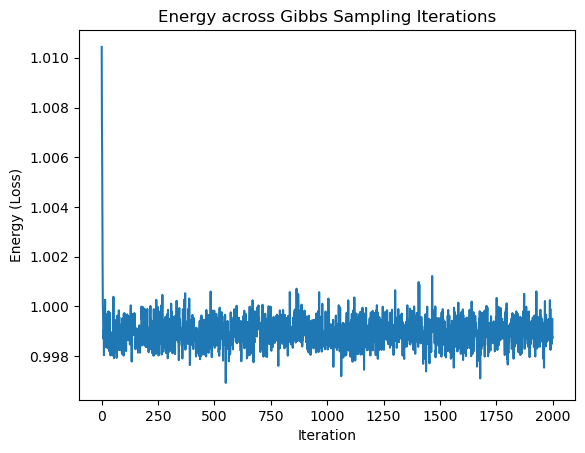

In [30]:
# Initialize U and V randomly uninformed
U_init = np.random.normal(0, 1, (k, d))
cluster_indices = np.random.choice(k, size=n)
V_init = np.eye(k)[cluster_indices]
T = 2000
energies, _ , U_samples, V_samples,  = gibbs_sampling(X, k, rho, U_true=None, V_true=None, T=2000, init='random')

# Plot energy across iterations to observe convergence
plt.plot(energies)
plt.xlabel("Iteration")
plt.ylabel("Energy (Loss)")
plt.title("Energy across Gibbs Sampling Iterations")
plt.show()


**Question 3 (1 pt):** Store the values $U_{t}$ and $V_{t}$ during Gibbs sampling. Compute the overlap of the labels assignment with respect to the ground truth from the formula above.


Plot the Ovelap with respect to the Gibbs sampling iterations. Distinguish two cases, to show in the same plot:

1) Random initialization of $U_{t=0}$ and $V_{t=0}$ (in blue);

2) Informed initialization of $U_{t=0}=U^*$ and $V_{t=0}=V^*$ to the ground truth, i.e. $U_{t=0}$ and $V_{t=0}$ (in orange).

Important note : the ground truth is never known in practice and thus you simply cannot use it. For practical applications you always have to initialize randomly (blue curve). However, for the scope of the excercise and following what has been done in the tutorials, you can see the difference when initializing directly to the correct values (orange curve).

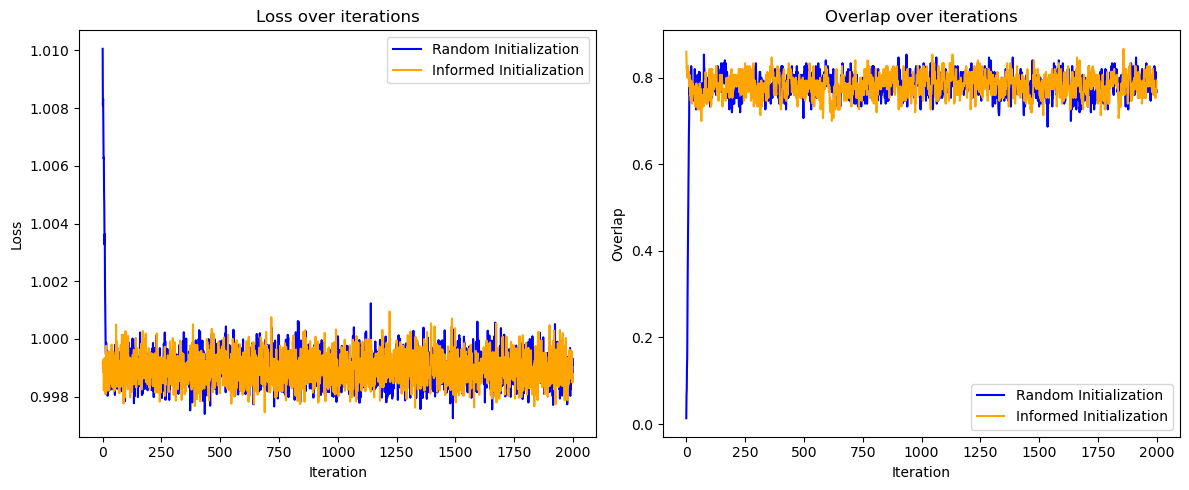

In [31]:
# Parameters
n, d, k = 300, 150, 2
T = 2000
rho = 4

# Random initialization
Loss_random, Overlap_random, _, _ = gibbs_sampling(X, k, rho, V_true=V_true, T=T, init='random')

# Informed initialization
Loss_informed, Overlap_informed, _, _ = gibbs_sampling(X, k, rho, U_true=U_true, V_true=V_true, T=T, init='informed')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(Loss_random, label='Random Initialization', color='blue')
plt.plot(Loss_informed, label='Informed Initialization', color='orange')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over iterations')

plt.subplot(1, 2, 2)
plt.plot(Overlap_random, label='Random Initialization', color='blue')
plt.plot(Overlap_informed, label='Informed Initialization', color='orange')
plt.xlabel('Iteration')
plt.ylabel('Overlap')
plt.legend()
plt.title('Overlap over iterations')

plt.tight_layout()
plt.show()

In [32]:
#this is just for better visualization, not needed to get full score.
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

window_size = 50

Loss_random_smoothed = moving_average(Loss_random, window_size)
Overlap_random_smoothed = moving_average(Overlap_random, window_size)
Loss_informed_smoothed = moving_average(Loss_informed, window_size)
Overlap_informed_smoothed = moving_average(Overlap_informed, window_size)

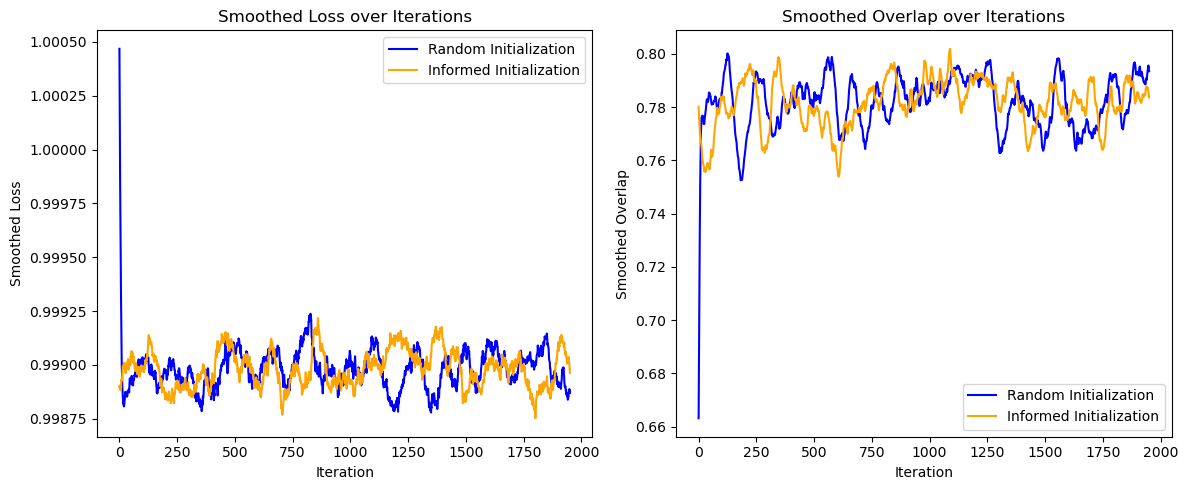

In [33]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(Loss_random_smoothed, label='Random Initialization', color='blue')
plt.plot(Loss_informed_smoothed, label='Informed Initialization', color='orange')
plt.xlabel('Iteration')
plt.ylabel('Smoothed Loss')
plt.legend()
plt.title('Smoothed Loss over Iterations')

plt.subplot(1, 2, 2)
plt.plot(Overlap_random_smoothed, label='Random Initialization', color='blue')
plt.plot(Overlap_informed_smoothed, label='Informed Initialization', color='orange')
plt.xlabel('Iteration')
plt.ylabel('Smoothed Overlap')
plt.legend()
plt.title('Smoothed Overlap over Iterations')

plt.tight_layout()
plt.show()

**Question 4 (1 pt):** Take $n=300$, $d=150$, $k=2$, $T = 1000$. Run Gibbs sampling with random initialization varying the parameter $\rho$ from 0 to 4 at steps of 0.1. For each value of rho, compute the mean overlap in the last steps (choose an appropriate value for convergence, same for T) and take also $n_{sim}=5$ different simulations in order to compute the standard deviation (in this question you are allowed to change the seed).

Plot the overlap with respect to the values of $\rho$ with error bars along the y-axis. Comment briefly the result.




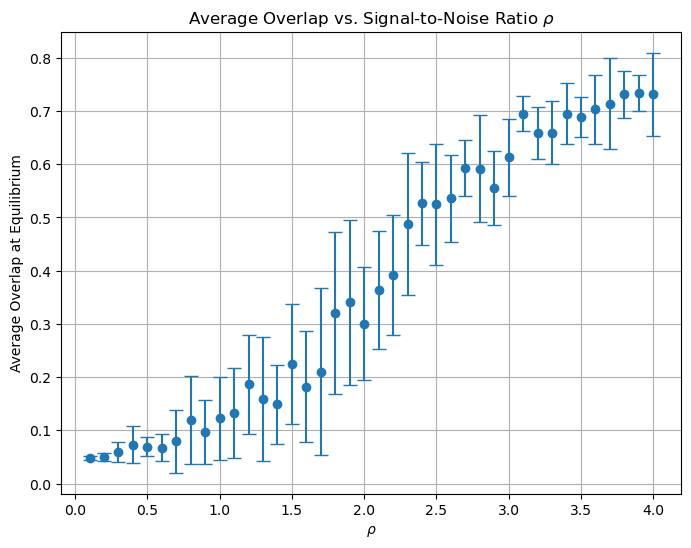

In [19]:
# Parameters
n, d, k = 300, 150, 2
T = 1000
rho_values = np.arange(0.1, 4.1, 0.1)
num_runs = 5
overlaps = np.zeros((len(rho_values), num_runs))

for i_rho, rho in enumerate(rho_values):
    for i_run in range(num_runs):
        X, U_true, V_true = generate_gmm_data(n, d, k, rho)
        # random initialization
        _, Overlap , _, _= gibbs_sampling(X, k, rho, V_true=V_true, T=T, init='random')
        # Take the mean of the last few overlap values to estimate equilibrium
        overlaps[i_rho, i_run] = np.mean(Overlap[-100:])

# mean and standard deviation across runs
overlaps_mean = overlaps.mean(axis=1)
overlaps_std = overlaps.std(axis=1)

plt.figure(figsize=(8, 6))
plt.errorbar(rho_values, overlaps_mean, yerr=overlaps_std, fmt='o', capsize=5)
plt.xlabel(r'$\rho$')
plt.ylabel('Average Overlap at Equilibrium')
plt.title(r'Average Overlap vs. Signal-to-Noise Ratio $\rho$')
plt.grid(True)
plt.show()

**Question 5 (1 pt):** Now increase $n$ and $d$, in particular take $n=1500$, $d=1500$, $k=2$, $T=2000$, $\rho=3$. Compute and print the value of the overlap in two different ways:

1) Fit a K-means algorithm on the $X$ data, you can use existing libaries in sklearn. Compute the overlap between the original ground truth and the labels found by K-means.

2) with the previous Gibbs algorithm, just print the last value.



In both cases, run $n_{sim}=3$ simulations and print the two overlaps in the format $mean \pm std$.

Print these two values and compare them.

In [16]:
from sklearn.cluster import KMeans
import random 

n, d, k = 1500, 1500, 2 #d=1000
rho = 3 #rho =3

np.random.seed(42)
random.seed(42)
X, U_true, V_true = generate_gmm_data(n, d, k, rho)

overlap_kmeans = []
num_runs = 3
for run in range(num_runs):
    # Set a different random state for each run
    random_state = run  # Or use None for completely random initialization

    # Run K-Means Clustering
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=random_state)
    kmeans_labels = kmeans.fit_predict(X)

    # Construct V_kmeans
    V_kmeans = np.zeros((n, k))
    V_kmeans[np.arange(n), kmeans_labels] = 1

    # Compute overlap for K-Means
    E_kmeans = compute_error_rate(V_kmeans, V_true)
    Overlap_kmeans = (E_kmeans - (1 / k)) / (1 - (1 / k))
    overlap_kmeans.append(Overlap_kmeans)

    print(f"Run {run + 1}: K-Means Overlap = {Overlap_kmeans:.4f}")

# Compute mean and std of the K-Means overlaps
mean_overlap_kmeans = np.mean(overlap_kmeans)
std_overlap_kmeans = np.std(overlap_kmeans)

print(f"\nK-Means Overlap: Mean = {mean_overlap_kmeans:.4f}, Std = {std_overlap_kmeans:.4f}")

Run 1: K-Means Overlap = 0.1253
Run 2: K-Means Overlap = 0.0573
Run 3: K-Means Overlap = 0.0333

K-Means Overlap: Mean = 0.0720, Std = 0.0390


In [17]:
n, d, k = 1500, 1500, 2 #d=1000
rho = 3 #rho =3
T = 2000

np.random.seed(42)
random.seed(42)

X, U_true, V_true = generate_gmm_data(n, d, k, rho)

overlap_gibbs_runs = []

num_runs = 3
for run in range(num_runs):
    np.random.seed(run)

    Loss_gibbs, Overlap_gibbs, _, V_gibbs = gibbs_sampling(X, k, rho, V_true=V_true, T=T)

    avg_overlap_last100 = np.mean(Overlap_gibbs[-100:])
    overlap_gibbs_runs.append(avg_overlap_last100)

    print(f"Run {run + 1}: Average Overlap over last 100 steps = {avg_overlap_last100:.4f}")

mean_overlap = np.mean(overlap_gibbs_runs)
std_overlap = np.std(overlap_gibbs_runs)

print(f"\nGibbs Sampling Overlap: Mean = {mean_overlap:.4f}, Std = {std_overlap:.4f}")

Run 1: Average Overlap over last 100 steps = 0.4483
Run 2: Average Overlap over last 100 steps = 0.4336
Run 3: Average Overlap over last 100 steps = 0.4417

Gibbs Sampling Overlap: Mean = 0.4412, Std = 0.0060
